In [1]:
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import pickle


import matplotlib.pyplot as plt
from matplotlib.pyplot import figure, show, savefig, close
import matplotlib.font_manager as fm
import itertools

import taurex
import xarray as xr
import os
import pandas as pd
import astropy

from taurex.cache import OpacityCache, CIACache
OpacityCache().set_opacity_path('./xsec/')
CIACache().set_cia_path('./cia/')

from taurex.temperature import TemperatureFile
from taurex.chemistry import TaurexChemistry
from taurex.chemistry import ConstantGas

from taurex.planet import Planet
from taurex.stellar import BlackbodyStar, PhoenixStar

from taurex.model import EmissionModel, TransmissionModel
from taurex.pressure import SimplePressureProfile

from taurex.contributions import AbsorptionContribution
from taurex.contributions import CIAContribution
from taurex.contributions import RayleighContribution

from taurex.binning import FluxBinner

from scipy.optimize import curve_fit


Numba not installed, using numpy instead


In [2]:
def bindown_single(w1, d1, w2, d2, output, noise, eclipses):
    wf = (w1 + w2) / 2
    df = (w2 + d2/2) - (w1 - d1/2)

    photogrid = np.array([[wf], [df]])

    fb2 = FluxBinner(photogrid[0], photogrid[1])

    # returns wavelength, value, and error
    wl, val, err, *_ = fb2.bindown(
        output[0], output[1],
        error=noise/np.sqrt(eclipses)
    )

    return w1, w2, wl[0], val[0], err[0], df

def make_next_level_points(results):
    """
    results: list of (w1, w2, wl, val, err, df)
             length must be even
    returns: list of (w1, d1, w2, d2)
    """

    assert len(results) % 2 == 0

    new_points = []

    for i in range(0, len(results), 2):
        left_bin  = results[i]
        right_bin = results[i + 1]

        # left edge of combined bin
        w1 = left_bin[2] - left_bin[5] / 2
        # right edge of combined bin
        w2 = right_bin[2] + right_bin[5] / 2

        width = w2 - w1

        new_points.append((w1, width, w2, width))

    return new_points

def bindown_multiple(output, noise, wlgrid, fpfs, eclipses, name, *new_points):
    all_results = []

    for (w1, d1, w2, d2) in new_points:
        out_i = bindown_single(w1, d1, w2, d2, output, noise, eclipses)
        all_results.append(out_i)

    return all_results

def create_point(w1, w2):
    wb1 = wb[np.argmin(np.abs(wl - w1))]
    wb2 = wb[np.argmin(np.abs(wl - w2))]
    point = (w1, wb1, w2, wb2)
    return point

In [15]:
# do this for one example planet for which we have a good nightside detection, then we can loop over all planets and all eclipse numbers to get a more complete picture of the nightside detection capabilities of JWST for USP planets.
# planet datasets

planet_names = ["HD3167","K2141","LHS1478","TOI431","TOI500","TOI561","TOI1416","TOI1807"]
planet_masses = [4.73, 4.97, 2.33, 3.07, 1.42, 2.02, 3.48, 2.44] #Earth masses
planet_distances = [0.018, 0.007, 0.018, 0.011, 0.012, 0.011, 0.019, 0.012] #AU
planet_period = [0.96, 0.28, 1.95, 0.49, 0.55, 0.45, 1.0, 0.55] #days
planet_radius = [1.627, 1.510, 1.242, 1.277, 1.166, 1.397, 1.620, 1.496] #Earth radii
planet_transit = [1.61, 0.94, 0.71, 1.24, 0.99, 1.31, 1.5, 0.98] #hours

star_temperature = [5261,4570,3381,4850,4440,5342,4884,4914] #Kelvin
star_radius = [0.872,0.681,0.246,0.731,0.678,0.856,0.793,0.746] #Solar radii
star_metallicity = [0.03, 0.0, -0.13, 0.2, 0.12, -0.4, 0.08, -0.04] #[Fe/H]
star_logg = [4.5, 4.6, 4.9, 4.6, 4.6, 4.5, 4.5, 4.6]
star_age = [10.2, 6.3, 5.6, 5.1, 5, 11, 6.9, 0.3] #Gyr

In [16]:
# Input parameters

name = planet_names[1] # <- input planet name
mass = planet_masses[planet_names.index(name)] #Earth masses
distance = planet_distances[planet_names.index(name)] #AU
period = planet_period[planet_names.index(name)] #days
radius = planet_radius[planet_names.index(name)] #Earth radii
transit = planet_transit[planet_names.index(name)] #hours

temperature = star_temperature[planet_names.index(name)] #Kelvin
star_rad = star_radius[planet_names.index(name)] #Solar radii
metallicity = star_metallicity[planet_names.index(name)] #[Fe/H]
logg = star_logg[planet_names.index(name)]
age = star_age[planet_names.index(name)] #Gyr

#star spectra
star = PhoenixStar(temperature=temperature, radius=star_rad, metallicity=metallicity, phoenix_path='Phoenix/')

#binning and noise
binning = False #binning on or off
sigma = 1 #sigma level for error bars 

#binning points
new_point9 = (4.305457, 0.28225, 4.5973, 0.3014)
new_point10 = (4.908865, 0.322, 5.24157, 0.344)

new_point11 = (5.59683967, 0.367, 5.97618103, 0.391)
new_point12 = (6.38, 0.418, 6.814, 0.447)

new_points = [new_point9, new_point10, new_point11, new_point12]

In [17]:
#define normalized blackbody function for fit
def planet_spectra(wavelength, temperature, scale):
    #relevant constants for blackbody calculation
    h = 6.62607015e-34 # Planck constant in J*s
    c = 299792458 # Speed of light in m/s
    k = 1.380649e-23 # Boltzmann constant in J/K

    wavelength = wavelength * 1e-6 # convert from micron to meter

    bb = (2 * h * c**2) / (wavelength**5 * (np.exp((h * c) / (wavelength * k * temperature)) - 1))

    return scale * (bb / star_flux_binned)

In [19]:
name = planet_names[1]
#save all simulation folders in each planet folder
for folder in os.listdir(f"PLANETS/{name}/"):
        if os.path.isdir(os.path.join(f"PLANETS/{name}/", folder)):
            print(folder)

H10_IW4_00001_S40
H10_IW4_00001_S10


Analysed for 1 observations. Mean temperature: 530.98 K, 3-sigma lower limit: 7.14 K, 3-sigma upper limit: 5000.00 K
1 observations for K2141 - H10_IW4_00001_S10; Mean temperature: 530.98 K, 3-sigma lower limit: 7.14 K, 3-sigma upper limit: 5000.00 K


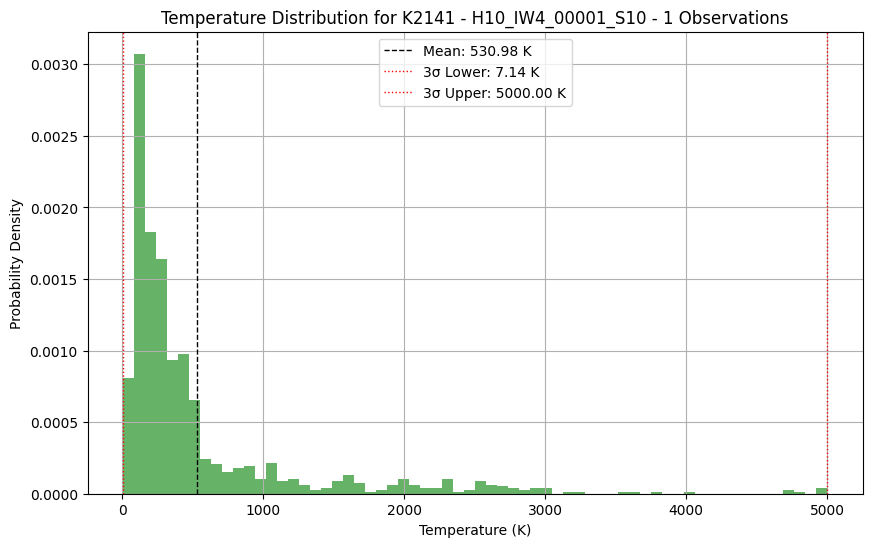

In [ ]:
folder = 'H10_IW4_00001_S10' # <- input folder name for simulation

simulation_folder = os.path.join(f"PLANETS/{name}/", folder)

#set-up directories and paths
outputdir = f"PLANETS/{name}/{os.path.basename(simulation_folder)}"
planetdir = f"PLANETS/{name}/{os.path.basename(simulation_folder)}_TP.csv"

temp_profile_terminator = TemperatureFile(planetdir, skiprows=1,
                            temp_col=1, press_col=0,
                            temp_units='K', press_units='Pa',
                            delimiter = ',')

atm_file = None
for file in os.listdir(f"PLANETS/{name}/{os.path.basename(simulation_folder)}/"):
    if file.endswith("atm.nc"):
        atm_file = os.path.join(f"PLANETS/{name}/{os.path.basename(simulation_folder)}/", file)
        #save filename without extension
        filename = os.path.splitext(atm_file)[0]
        break

ds = xr.open_dataset(atm_file)

#extract gas names
gases = np.array(ds['gases'])
gases = [m.decode().strip() for m in ds["gases"].values]
vmr = np.array(ds['x_gas'])

pressure = np.array(ds['p']) #pressure in Pa
pmax = pressure.max()
pmin = pressure.min()

radius = float(ds['planet_radius']) #planet radius in m
#convert to Jupiter radii
radius = radius / astropy.constants.R_jup.value

#get mixing ratio of each molecule
H2O_x = float(vmr[:, gases.index('H2O')][0])
CO2_x = float(vmr[:, gases.index('CO2')][0])
CH4_x = float(vmr[:, gases.index('CH4')][0])
CO_x = float(vmr[:, gases.index('CO')][0])
NH3_x = float(vmr[:, gases.index('NH3')][0])
N2_x = float(vmr[:, gases.index('N2')][0])
SO2_x = float(vmr[:, gases.index('SO2')][0])
S2_x = float(vmr[:, gases.index('S2')][0])
O2_x = float(vmr[:, gases.index('O2')][0])
H2_x = float(vmr[:, gases.index('H2')][0])
H2S_x = float(vmr[:, gases.index('H2S')][0])

#define chemistry
chemistry = TaurexChemistry(fill_gases=["N2"])

# check that the sum of all vmr is less or equal to 1
total_vmr = H2O_x + CO2_x + CH4_x + CO_x + NH3_x + N2_x + SO2_x + S2_x + O2_x + H2_x + H2S_x
if total_vmr > 1:
    #renormalize the vmr values
    H2O_x = H2O_x / total_vmr
    CO2_x = CO2_x / total_vmr
    CH4_x = CH4_x / total_vmr
    CO_x = CO_x / total_vmr
    NH3_x = NH3_x / total_vmr
    N2_x = N2_x / total_vmr
    SO2_x = SO2_x / total_vmr
    S2_x = S2_x / total_vmr
    O2_x = O2_x / total_vmr
    H2_x = H2_x / total_vmr
    H2S_x = H2S_x / total_vmr

chemistry.addGas(ConstantGas(molecule_name="NH3", mix_ratio=NH3_x)).addGas(ConstantGas(molecule_name="CO2", mix_ratio=CO2_x)).addGas(ConstantGas(molecule_name="H2O", mix_ratio=H2O_x)).addGas(ConstantGas(molecule_name="CH4", mix_ratio=CH4_x)).addGas(ConstantGas(molecule_name="CO", mix_ratio=CO_x)).addGas(ConstantGas(molecule_name="SO2", mix_ratio=SO2_x)).addGas(ConstantGas(molecule_name="S2", mix_ratio=S2_x)).addGas(ConstantGas(molecule_name="O2", mix_ratio=O2_x)).addGas(ConstantGas(molecule_name="H2", mix_ratio=H2_x)).addGas(ConstantGas(molecule_name="H2S", mix_ratio=H2S_x))

#convert to jupiter masses without mutating input mass
mass_jup = mass / 317.8
#set-up planet in Jupiter masses and radii
planet = Planet(planet_mass=mass_jup, planet_radius= radius, planet_distance=distance)

star = PhoenixStar(temperature=temperature, radius=star_rad, metallicity=metallicity, phoenix_path='Phoenix/')

#build emission model at the terminator
em_terminator = EmissionModel( 
planet=planet,
temperature_profile=temp_profile_terminator,
chemistry=chemistry,
pressure_profile=SimplePressureProfile(atm_min_pressure=pmin, atm_max_pressure=pmax, nlayers=100),
star=star,
)

em_terminator.add_contribution(AbsorptionContribution())
em_terminator.add_contribution(CIAContribution(cia_pairs=['CO2-CH4','CO2-CO2','CO2-H2','CO2-H2O','H2-H2','N2-CH4','N2-H2','N2-H2O','N2-N2','O2-CO2','O2-N2','O2-O2']))
em_terminator.add_contribution(RayleighContribution())

em_terminator.build()

#wavenumber grid, flux ratio, and transit depth
wngrid_t, fpfs_t, tau_t, _ = em_terminator.model()

wlgrid_t = 10000/wngrid_t[::-1]
fpfs_t = fpfs_t[::-1]

#read-in Ariel noise model
if os.path.exists(f"ARIEL/arielrad_{name}/tier2.csv"):
    file = f"ARIEL/arielrad_{name}/tier2.csv"

ariel = pd.read_csv(file,skiprows=6)
wl = np.array(ariel['Wavelength [um]'])
wb = np.array(ariel['Bandwidth [um]'])
noise = np.array(ariel['Noise on Transit Floor [ppm]']) * 1e-6 #converts ppm to fractional

# instantiate flux binner with Ariel's wavelength binning
fb = FluxBinner(wl, wb)
output_t = fb.bindown(wlgrid_t, fpfs_t)
wl, val, err, *_ = output_t

locals()[f"T_{name}_{os.path.basename(simulation_folder)}"] = []

#extract star spectrum on the SAME model grid as fpfs_t
star_flux_model = np.asarray(star.spectralEmissionDensity)
star_wl_model = 10000 / np.asarray(wngrid_t)

n_star = min(star_flux_model.size, star_wl_model.size)
star_flux_model = star_flux_model[:n_star]
star_wl_model = star_wl_model[:n_star]

sort_idx = np.argsort(star_wl_model)
star_wl_model = star_wl_model[sort_idx]
star_flux_model = star_flux_model[sort_idx]

output_star = fb.bindown(star_wl_model, star_flux_model)
star_wl_binned, star_flux_binned, star_err, *_ = output_star

#fidn lowest number of obs before 3-sigma lower limit for temperature is above 0K
for obs in np.arange(1,100,1):
    #create an iteration of the spectra using the noise and binning of Ariel. at every point generate a WGN with mean at val and sigma equal to the noise
    for n in range(1000):
        val_noise = np.zeros_like(val)
        for i in range(len(val)):
            #generate WGN with mean at val and sigma equal to the noise
            val_noise[i] = np.random.normal(loc=val[i], scale=noise[i]/np.sqrt(obs))


        p0 = [1000.0, 1e-7]
        bounds = ([0.0, 1e-20], [5000.0, 1.0])
        popt, pcov = curve_fit(planet_spectra, wl, val_noise, p0=p0, bounds=bounds, maxfev=20000)

        locals()[f"T_{name}_{os.path.basename(simulation_folder)}"].append(popt[0])


    temperature_dist = np.array(locals()[f"T_{name}_{os.path.basename(simulation_folder)}"])

    #find mean and std of temperature distribution
    mean_temp = np.mean(temperature_dist)
    std_temp = np.std(temperature_dist)

    #find 3 sigma confidence interval
    q_low, q_high = np.percentile(temperature_dist, [0.135, 99.865])

    # find 5 sigma confidence interval
    q_low_5, q_high_5 = np.percentile(temperature_dist, [0.000057, 99.999943])

    print(f"Analysed for {obs} observations. Mean temperature: {mean_temp:.2f} K, 3-sigma lower limit: {q_low:.2f} K, 3-sigma upper limit: {q_high:.2f} K")

    if q_low > 0:
        print(f"{obs} observations for {name} - {os.path.basename(simulation_folder)}; Mean temperature: {mean_temp:.2f} K, 3-sigma lower limit: {q_low:.2f} K, 3-sigma upper limit: {q_high:.2f} K")

        fig = figure(figsize=(10, 6))
        plt.hist(temperature_dist, bins='auto', density=True, alpha=0.6, color='g')
        plt.axvline(mean_temp, color='k', linestyle='dashed', linewidth=1,label=f'Mean: {mean_temp:.2f} K')

        plt.axvline(q_low, color='r', linestyle='dotted', linewidth=1, label=f'3σ Lower: {q_low:.2f} K')
        plt.axvline(q_high, color='r', linestyle='dotted', linewidth=1, label=f'3σ Upper: {q_high:.2f} K')

        plt.axvline(q_low_5, color='b', linestyle='dashdot', linewidth=1, label=f'5σ Lower: {q_low_5:.2f} K')
        plt.axvline(q_high_5, color='b', linestyle='dashdot', linewidth=1, label=f'5σ Upper: {q_high_5:.2f} K')

        plt.xlabel('Temperature (K)')
        plt.ylabel('Probability Density')
        plt.title(f'Temperature Distribution for {name} - {os.path.basename(simulation_folder)} - {obs} Observations')
        plt.grid()
        plt.legend()
        plt.show()

        break

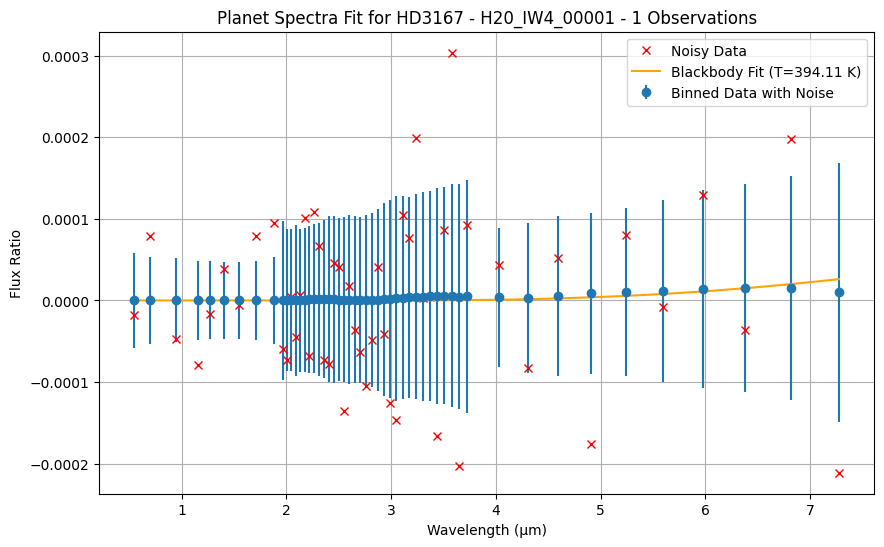

In [14]:
#show the fit of the planet spectra with the mean temperature
plt.figure(figsize=(10, 6))
plt.errorbar(wl, val, yerr=noise/np.sqrt(obs), fmt='o', label='Binned Data with Noise')
plt.plot(wl,val_noise, 'x', label='Noisy Data', color='red')

plt.plot(wl, planet_spectra(wl, mean_temp, popt[1]), label=f'Blackbody Fit (T={mean_temp:.2f} K)', color='orange')

plt.xlabel('Wavelength (µm)')
plt.ylabel('Flux Ratio')
plt.title(f'Planet Spectra Fit for {name} - {os.path.basename(simulation_folder)} - {obs} Observations')
plt.grid()
plt.legend()
plt.show()